# Multiple Linear Regression

In [41]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [42]:
df=pd.read_csv('ToyotaCorolla - MLR.csv')

In [43]:
df

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,Diesel,90,0,2000,3,4,5,1165
1,13750,23,72937,Diesel,90,0,2000,3,4,5,1165
2,13950,24,41711,Diesel,90,0,2000,3,4,5,1165
3,14950,26,48000,Diesel,90,0,2000,3,4,5,1165
4,13750,30,38500,Diesel,90,0,2000,3,4,5,1170
...,...,...,...,...,...,...,...,...,...,...,...
1431,7500,69,20544,Petrol,86,0,1300,3,4,5,1025
1432,10845,72,19000,Petrol,86,0,1300,3,4,5,1015
1433,8500,71,17016,Petrol,86,0,1300,3,4,5,1015
1434,7250,70,16916,Petrol,86,0,1300,3,4,5,1015


### Tasks:
### 1.Perform exploratory data analysis (EDA) to gain insights into the dataset. Provide visualizations and summary statistics of the variables. Pre-process the data to apply the MLR.


In [44]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1436 entries, 0 to 1435
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Price      1436 non-null   int64 
 1   Age_08_04  1436 non-null   int64 
 2   KM         1436 non-null   int64 
 3   Fuel_Type  1436 non-null   object
 4   HP         1436 non-null   int64 
 5   Automatic  1436 non-null   int64 
 6   cc         1436 non-null   int64 
 7   Doors      1436 non-null   int64 
 8   Cylinders  1436 non-null   int64 
 9   Gears      1436 non-null   int64 
 10  Weight     1436 non-null   int64 
dtypes: int64(10), object(1)
memory usage: 123.5+ KB


In [45]:
df.isnull().sum()

Price        0
Age_08_04    0
KM           0
Fuel_Type    0
HP           0
Automatic    0
cc           0
Doors        0
Cylinders    0
Gears        0
Weight       0
dtype: int64

In [46]:
df.duplicated().sum()

np.int64(1)

In [47]:
newdf=df.drop_duplicates()

In [48]:
newdf.duplicated().sum()

np.int64(0)

In [49]:
newdf.describe()

,Price,Age_08_04,KM,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
count,1435.000000,1435.000000,1435.000000,1435.000000,1435.000000,1435.000000,1435.000000,1435.0,1435.000000,1435.000000
mean,10720.915679,55.980488,68571.782578,101.491986,0.055749,1576.560976,4.032753,4.0,5.026481,1072.287108
std,3608.732978,18.563312,37491.094553,14.981408,0.229517,424.387533,0.952667,0.0,0.188575,52.251882
min,4350.000000,1.000000,1.000000,69.000000,0.000000,1300.000000,2.000000,4.0,3.000000,1000.000000
25%,8450.000000,44.000000,43000.000000,90.000000,0.000000,1400.000000,3.000000,4.0,5.000000,1040.000000
50%,9900.000000,61.000000,63451.000000,110.000000,0.000000,1600.000000,4.000000,4.0,5.000000,1070.000000
75%,11950.000000,70.000000,87041.500000,110.000000,0.000000,1600.000000,5.000000,4.0,5.000000,1085.000000
max,32500.000000,80.000000,243000.000000,192.000000,1.000000,16000.000000,5.000000,4.0,6.000000,1615.000000


In [50]:
newdf.shape

(1435, 11)

## Data Trnsformation

In [51]:
# Label Encoding
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
newdf['Fuel_Type'] = le.fit_transform(newdf['Fuel_Type'])

C:\Users\Yashwant\AppData\Local\Temp\ipykernel_2920\3288585484.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  newdf['Fuel_Type'] = le.fit_transform(newdf['Fuel_Type'])


In [52]:
newdf

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,1,90,0,2000,3,4,5,1165
1,13750,23,72937,1,90,0,2000,3,4,5,1165
2,13950,24,41711,1,90,0,2000,3,4,5,1165
3,14950,26,48000,1,90,0,2000,3,4,5,1165
4,13750,30,38500,1,90,0,2000,3,4,5,1170
...,...,...,...,...,...,...,...,...,...,...,...
1431,7500,69,20544,2,86,0,1300,3,4,5,1025
1432,10845,72,19000,2,86,0,1300,3,4,5,1015
1433,8500,71,17016,2,86,0,1300,3,4,5,1015
1434,7250,70,16916,2,86,0,1300,3,4,5,1015


In [53]:
newdf.tail()

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
1431,7500,69,20544,2,86,0,1300,3,4,5,1025
1432,10845,72,19000,2,86,0,1300,3,4,5,1015
1433,8500,71,17016,2,86,0,1300,3,4,5,1015
1434,7250,70,16916,2,86,0,1300,3,4,5,1015
1435,6950,76,1,2,110,0,1600,5,4,5,1114


## Data Visualization 

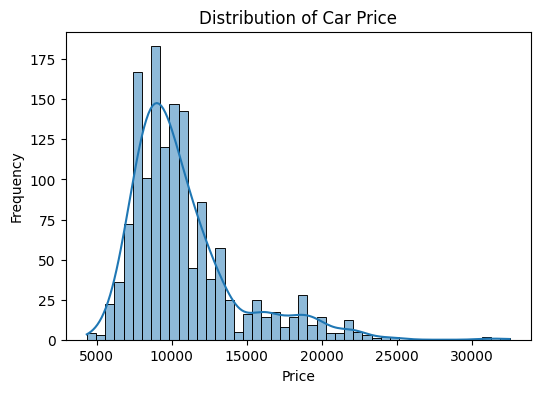

In [54]:
# Distribution of Target Variable (Price)
plt.figure(figsize=(6,4))
sns.histplot(newdf['Price'], kde=True)
plt.title("Distribution of Car Price")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

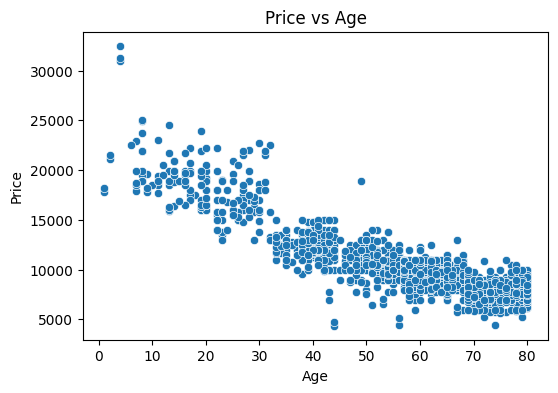

In [55]:
plt.figure(figsize=(6,4))
sns.scatterplot(x=newdf['Age_08_04'], y=newdf['Price'])
plt.title("Price vs Age")
plt.xlabel("Age")
plt.ylabel("Price")
plt.show()

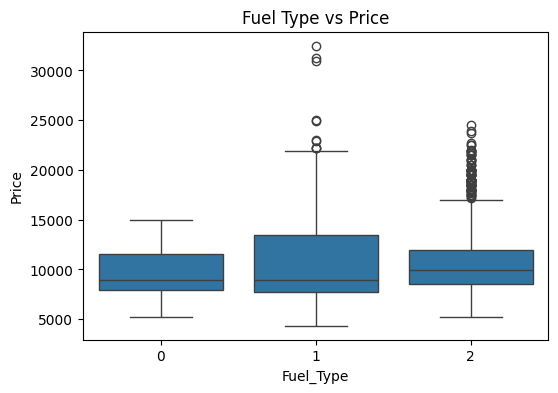

In [56]:
plt.figure(figsize=(6,4))
sns.boxplot(x=newdf['Fuel_Type'], y=newdf['Price'])
plt.title("Fuel Type vs Price")
plt.show()

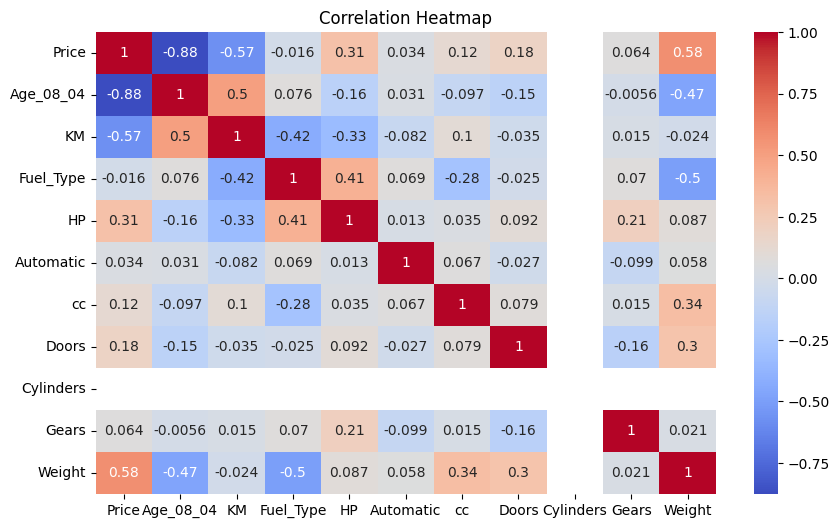

In [57]:
plt.figure(figsize=(10,6))
sns.heatmap(newdf.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [58]:
df_cont=newdf.iloc[:,:]
df_cont

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,13500,23,46986,1,90,0,2000,3,4,5,1165
1,13750,23,72937,1,90,0,2000,3,4,5,1165
2,13950,24,41711,1,90,0,2000,3,4,5,1165
3,14950,26,48000,1,90,0,2000,3,4,5,1165
4,13750,30,38500,1,90,0,2000,3,4,5,1170
...,...,...,...,...,...,...,...,...,...,...,...
1431,7500,69,20544,2,86,0,1300,3,4,5,1025
1432,10845,72,19000,2,86,0,1300,3,4,5,1015
1433,8500,71,17016,2,86,0,1300,3,4,5,1015
1434,7250,70,16916,2,86,0,1300,3,4,5,1015


In [59]:
from sklearn.preprocessing import StandardScaler
SS=StandardScaler()
SS_X=SS.fit_transform(df_cont)
SS_X

array([[ 0.77036821, -1.77726827, -0.57595832, ...,  0.        ,
        -0.14047507,  1.77496405],
       [ 0.83966875, -1.77726827,  0.11647404, ...,  0.        ,
        -0.14047507,  1.77496405],
       [ 0.89510918, -1.72337979, -0.71670745, ...,  0.        ,
        -0.14047507,  1.77496405],
       ...,
       [-0.61564265,  0.80937864, -1.37562683, ...,  0.        ,
        -0.14047507, -1.09674669],
       [-0.96214536,  0.75549016, -1.37829506, ...,  0.        ,
        -0.14047507, -1.09674669],
       [-1.04530601,  1.07882103, -1.82962616, ...,  0.        ,
        -0.14047507,  0.7985824 ]], shape=(1435, 11))

In [62]:
scaled_data=pd.DataFrame(SS_X, columns=df_cont.columns, index=df_cont.index)

In [63]:
scaled_data

,Price,Age_08_04,KM,Fuel_Type,HP,Automatic,cc,Doors,Cylinders,Gears,Weight
0,0.770368,-1.777268,-0.575958,-2.343149,-0.767351,-0.242983,0.998113,-1.084443,0.0,-0.140475,1.774964
1,0.839669,-1.777268,0.116474,-2.343149,-0.767351,-0.242983,0.998113,-1.084443,0.0,-0.140475,1.774964
2,0.895109,-1.723380,-0.716707,-2.343149,-0.767351,-0.242983,0.998113,-1.084443,0.0,-0.140475,1.774964
3,1.172311,-1.615603,-0.548902,-2.343149,-0.767351,-0.242983,0.998113,-1.084443,0.0,-0.140475,1.774964
4,0.839669,-1.400049,-0.802384,-2.343149,-0.767351,-0.242983,0.998113,-1.084443,0.0,-0.140475,1.870688
...,...,...,...,...,...,...,...,...,...,...,...
1431,-0.892845,0.701602,-1.281492,0.353257,-1.034441,-0.242983,-0.651898,-1.084443,0.0,-0.140475,-0.905299
1432,0.034396,0.863267,-1.322689,0.353257,-1.034441,-0.242983,-0.651898,-1.084443,0.0,-0.140475,-1.096747
1433,-0.615643,0.809379,-1.375627,0.353257,-1.034441,-0.242983,-0.651898,-1.084443,0.0,-0.140475,-1.096747
1434,-0.962145,0.755490,-1.378295,0.353257,-1.034441,-0.242983,-0.651898,-1.084443,0.0,-0.140475,-1.096747


In [64]:
y=scaled_data['Price']
X=scaled_data.drop('Price', axis=1)

# 2.Split the dataset into training and testing sets (e.g., 80% training, 20% testing).

In [65]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test= train_test_split(X,y, test_size=0.2, random_state=1)

In [86]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 3.Build a multiple linear regression model using the training dataset. Interpret the coefficients of the model. Build a minimum of 3 different models.

In [66]:
from sklearn.linear_model import LinearRegression

In [125]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

print("Linear Regression R2:", r2_score(y_test, y_pred_lr))


Linear Regression R2: 0.8136980992304216


# Lasso Regression

In [100]:
from sklearn.linear_model import Lasso

In [128]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

y_pred_lasso = lasso.predict(X_test_scaled)

print("Lasso R2:", r2_score(y_test, y_pred_lasso))


Lasso R2: 0.8419449073238712


# Ridge Regression

In [105]:
from sklearn.linear_model import Ridge

In [129]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

y_pred_ridge = ridge.predict(X_test_scaled)

print("Ridge R2:", r2_score(y_test, y_pred_ridge))


Ridge R2: 0.8144704717131759


### Coefficiant Interpretation

In [130]:
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
})

print(coeff_df.sort_values(by='Coefficient', ascending=False))

     Feature   Coefficient
9     Weight  2.970057e-01
3         HP  1.208958e-01
8      Gears  3.157017e-02
4  Automatic  2.283130e-02
2  Fuel_Type  1.395831e-02
7  Cylinders  6.938894e-18
6      Doors -6.290892e-03
5         cc -5.819478e-02
1         KM -1.688955e-01
0  Age_08_04 -6.360902e-01


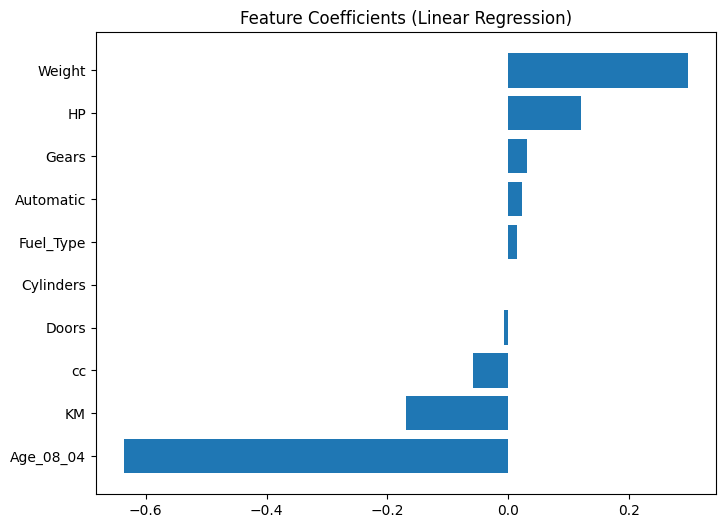

In [131]:
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
}).sort_values(by='Coefficient')

plt.figure(figsize=(8,6))
plt.barh(coeff_df['Feature'], coeff_df['Coefficient'])
plt.title("Feature Coefficients (Linear Regression)")
plt.show()


### Model Evaluation Metrics

In [139]:
def evaluate_model(y_test, y_pred_lr, Linear_Model):
    
    print(f"\n{Linear_Model} Performance")
    print("MAE:", mean_absolute_error(y_test, y_pred_lr))
    print("MSE:", mean_squared_error(y_test, y_pred_lr))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
    print("R2 Score:", r2_score(y_test, y_pred_lr))

In [140]:
evaluate_model(y_test, y_pred_lr, "Linear Regression")
evaluate_model(y_test, y_pred_lasso, "Lasso Regression")
evaluate_model(y_test, y_pred_ridge, "Ridge Regression")


Linear Regression Performance
MAE: 0.2882025912532754
MSE: 0.20832702869015177
RMSE: 0.4564285581448117
R2 Score: 0.8136980992304216

Lasso Regression Performance
MAE: 0.2977397358250273
MSE: 0.17674080452506694
RMSE: 0.42040552389932623
R2 Score: 0.8419449073238712

Ridge Regression Performance
MAE: 0.28811321119315914
MSE: 0.20746334418822468
RMSE: 0.45548144219959685
R2 Score: 0.8144704717131759


# MLR Interview Question Answer

### What is Normalization & Standardization and how is it helpful?

## Normalization

#### Normalization is a feature scaling technique that rescale values to a fixed range, usually 0 and 1.

### When to Use

##### Distance-based algorithms
##### (KNN, K-Means, DBSCAN)
##### Neural Networks (faster convergence)
##### When data does not follow a normal distribution

## Standardization
##### Standardization rescales data to have. Mean = 0, Standard Deviation = 1

### When to Use
##### Linear Regression
##### Logistic Regression
##### SVM
##### PCA
##### Algorithms assuming Gaussian distribution

## How it is helpful
#### Normalization and Standardization are feature scaling techniques used in data preprocessing. They make numerical features comparable by bringing them to a similar scale, which directly improves model performance, stability, and training speed.

## What techniques can be used to address multicollinearity in multiple linear regression?

#### Multicollinearity occurs when two or more independent variables in a regression model are highly correlated. This makes coefficient estimates unstable, increases their standard errors, and reduces the reliability of interpretation.


## Techniques:
#### Detect Multicollinearity
#### Remove One of the Correlated Variables
#### Combine Correlated Variables
#### Variance Inflation Factor (VIF)-Based Feature Selection
#### Regularization Techniques
#### Principal Component Analysis (PCA)